In [ ]:
import os
from pathlib import Path
from dotenv import load_dotenv

load_dotenv(Path('..') / '.env')
FRED_API_KEY = os.getenv('FRED_API_KEY')
if not FRED_API_KEY:
    raise RuntimeError('FRED_API_KEY is not set. Copy .env.example to .env')
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
from fredapi import Fred
import numpy as np

plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False
fred = Fred(api_key=FRED_API_KEY)
start_date = '1950-07-01'
end_date = '2025-11-06'
merge_column = 'Date'

In [83]:
series_id = 'FEDFUNDS'
data = fred.get_series(series_id, start_date, end_date)
data = data.resample('M').ffill()
df = pd.DataFrame(data, columns=['금리'])
df.index.name = merge_column
df = df.reset_index()
df

C:\Users\kimse\AppData\Local\Temp\ipykernel_14420\2761129209.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data = data.resample('M').ffill()


,Date,금리
0,1954-07-31,0.80
1,1954-08-31,1.22
2,1954-09-30,1.07
3,1954-10-31,0.85
4,1954-11-30,0.83
...,...,...
851,2025-06-30,4.33
852,2025-07-31,4.33
853,2025-08-31,4.33
854,2025-09-30,4.22


In [84]:
df.columns

Index(['Date', '금리'], dtype='object')

In [85]:
#df.to_csv("../data/rate_data.csv")

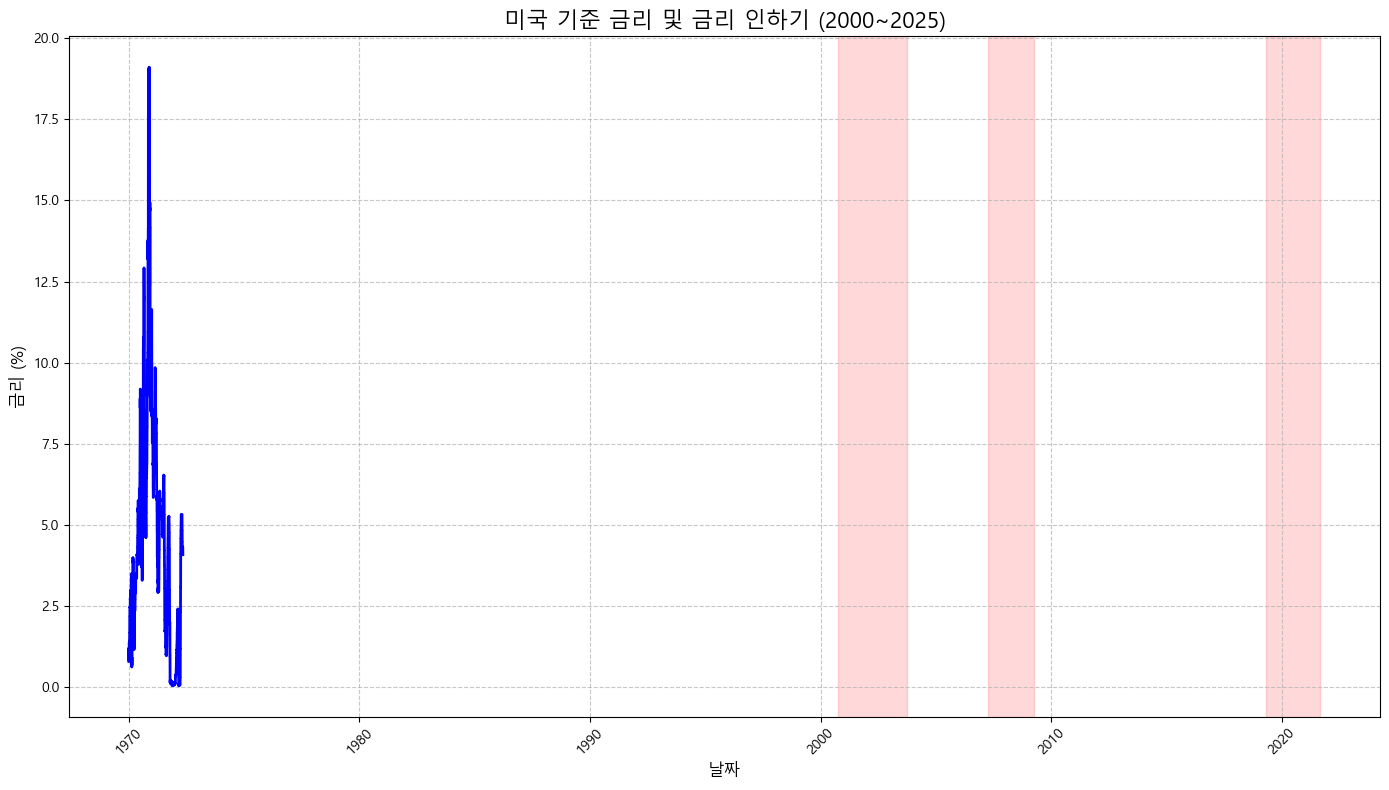

In [ ]:
recession_periods = [
    (pd.to_datetime('2000'), pd.to_datetime('2004').to_period('Y').end_time),
    (pd.to_datetime('2007'), pd.to_datetime('2012').to_period('Y').end_time),
    (pd.to_datetime('2019'), pd.to_datetime('2023').to_period('Y').end_time),
]

fig, ax = plt.subplots(figsize=(14, 8))
ax.plot(df.index, df['금리'], label='미국 기준 금리 (%)', color='blue', drawstyle='steps-post', linewidth=2)

for start, end in recession_periods:
    ax.axvspan(start, end, color='red', alpha=0.15, label='금리 인하기' if start == recession_periods[0][0] else "") 

ax.set_title('미국 기준 금리 및 금리 인하기 (2000~2025)', fontsize=16)
ax.set_xlabel('날짜', fontsize=12)
ax.set_ylabel('금리 (%)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout() 
plt.show()

In [ ]:
reduct_periods=recession_periods

In [ ]:
tickers = ['QQQ', 'XLP', 'XLY', 'BTC-USD', 'GC=F']
data_df = yf.download(tickers, start_date, end_date)['Close']

home_df = fred.get_series('CSUSHPINSA', start_date, end_date).resample('D').ffill()
home_df.name = 'home'

rate_df = fred.get_series('FEDFUNDS', start_date, end_date).resample('D').ffill()
rate_df.name = 'rate'

#cpi_df = fred.get_series('CPIAUCSL', start_date, end_date).resample('D').ffill()
#cpi_df.name = 'cpi'

fred_df = pd.concat([home_df, rate_df], axis = 1).resample('D').ffill()

df_final = data_df.join(fred_df, how = 'left')
df_final = df_final.dropna(subset=['QQQ'])

final_data = []
count =1
for start, end in reduct_periods:
    df_temp = df_final.loc[start:end].copy()
    df_temp['period']=count
    final_data.append(df_temp)
    count += 1
final_data = pd.concat(final_data)
final_data.index.name = merge_column
final_data.reset_index(inplace=True)



#final_data['rate'] = final_data['rate'].fillna(4.09)
#final_data['cpi'] = final_data['cpi'].fillna(323.364)

final_data

C:\Users\kimse\AppData\Local\Temp\ipykernel_14420\3049265791.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_df = yf.download(tickers, start_date, end_date)['Close']
[*********************100%***********************]  5 of 5 completed


,Date,BTC-USD,GC=F,QQQ,XLP,XLY,home,rate,period
0,2000-09-01,NaN,277.000000,86.791290,12.984960,18.968504,107.137,6.52,1
1,2000-09-05,NaN,275.799988,84.148422,12.942464,19.166710,107.137,6.52,1
2,2000-09-06,NaN,274.200012,81.188446,12.781004,19.446520,107.137,6.52,1
3,2000-09-07,NaN,274.000000,82.985611,12.899978,19.283298,107.137,6.52,1
4,2000-09-08,NaN,273.299988,80.448471,12.891478,19.644720,107.137,6.52,1
...,...,...,...,...,...,...,...,...,...
2178,2025-10-30,108305.546875,4001.300049,626.049988,76.500000,233.750000,NaN,4.09,4
2179,2025-10-31,109556.164062,3982.199951,629.070007,76.279999,239.929993,NaN,4.09,4
2180,2025-11-03,106547.523438,4000.300049,632.080017,75.680000,242.179993,NaN,4.09,4
2181,2025-11-04,101590.523438,3947.699951,619.250000,75.989998,238.160004,NaN,4.09,4


In [90]:
final_data.columns

Index(['Date', 'BTC-USD', 'GC=F', 'QQQ', 'XLP', 'XLY', 'home', 'rate',
       'period'],
      dtype='object')

In [91]:
merged_df = pd.merge(rate_df, final_data, how ='inner')
merged_df = merged_df[['Date'] + [col for col in merged_df.columns if col != 'Date']]
merged_df

,Date,rate,BTC-USD,GC=F,QQQ,XLP,XLY,home,period
0,2003-06-02,1.22,NaN,366.000000,25.016186,11.363358,20.582401,133.226,1
1,2003-06-03,1.22,NaN,365.200012,25.252989,11.476874,20.551897,133.226,1
2,2003-06-04,1.22,NaN,362.600006,25.726585,11.562019,20.872179,133.226,1
3,2003-06-05,1.22,NaN,368.600006,25.912643,11.573370,20.986568,133.226,1
4,2003-06-06,1.22,NaN,363.700012,25.481335,11.533632,20.879803,133.226,1
...,...,...,...,...,...,...,...,...,...
340052,2025-10-30,4.09,108305.546875,4001.300049,626.049988,76.500000,233.750000,NaN,4
340053,2025-10-31,4.09,109556.164062,3982.199951,629.070007,76.279999,239.929993,NaN,4
340054,2025-11-03,4.09,106547.523438,4000.300049,632.080017,75.680000,242.179993,NaN,4
340055,2025-11-04,4.09,101590.523438,3947.699951,619.250000,75.989998,238.160004,NaN,4


In [92]:
merged_df.to_csv("../data/finance_data.csv",index=False)

In [ ]:
# from sklearn.preprocessing import StandardScaler
# from sklearn.impute import KNNImputer

# scaler = StandardScaler()
# non_feature_cols = final_data[['Date', 'period']]
# feature_cols = ['QQQ', 'XLP', 'XLY', 'BTC-USD', 'GC=F', 'home', 'rate', 'cpi']
# df_features = final_data[feature_cols]

# scaler = StandardScaler()

# scaled_features = scaler.fit_transform(df_features)

# imputer = KNNImputer(n_neighbors=5, weights='uniform')
# imputed_scaled_features = imputer.fit_transform(scaled_features)

# imputed_features = scaler.inverse_transform(imputed_scaled_features)

# df_imputed = pd.DataFrame(imputed_features, columns=feature_cols)

# non_feature_cols = non_feature_cols.reset_index(drop=True)
# df_imputed = df_imputed.reset_index(drop=True)

# final_data_imputed = pd.concat([non_feature_cols, df_imputed], axis=1)

# final_data = final_data_imputed.set_index('Date')
# final_data


In [ ]:
#final_data.to_csv("../data/finance_data.csv")

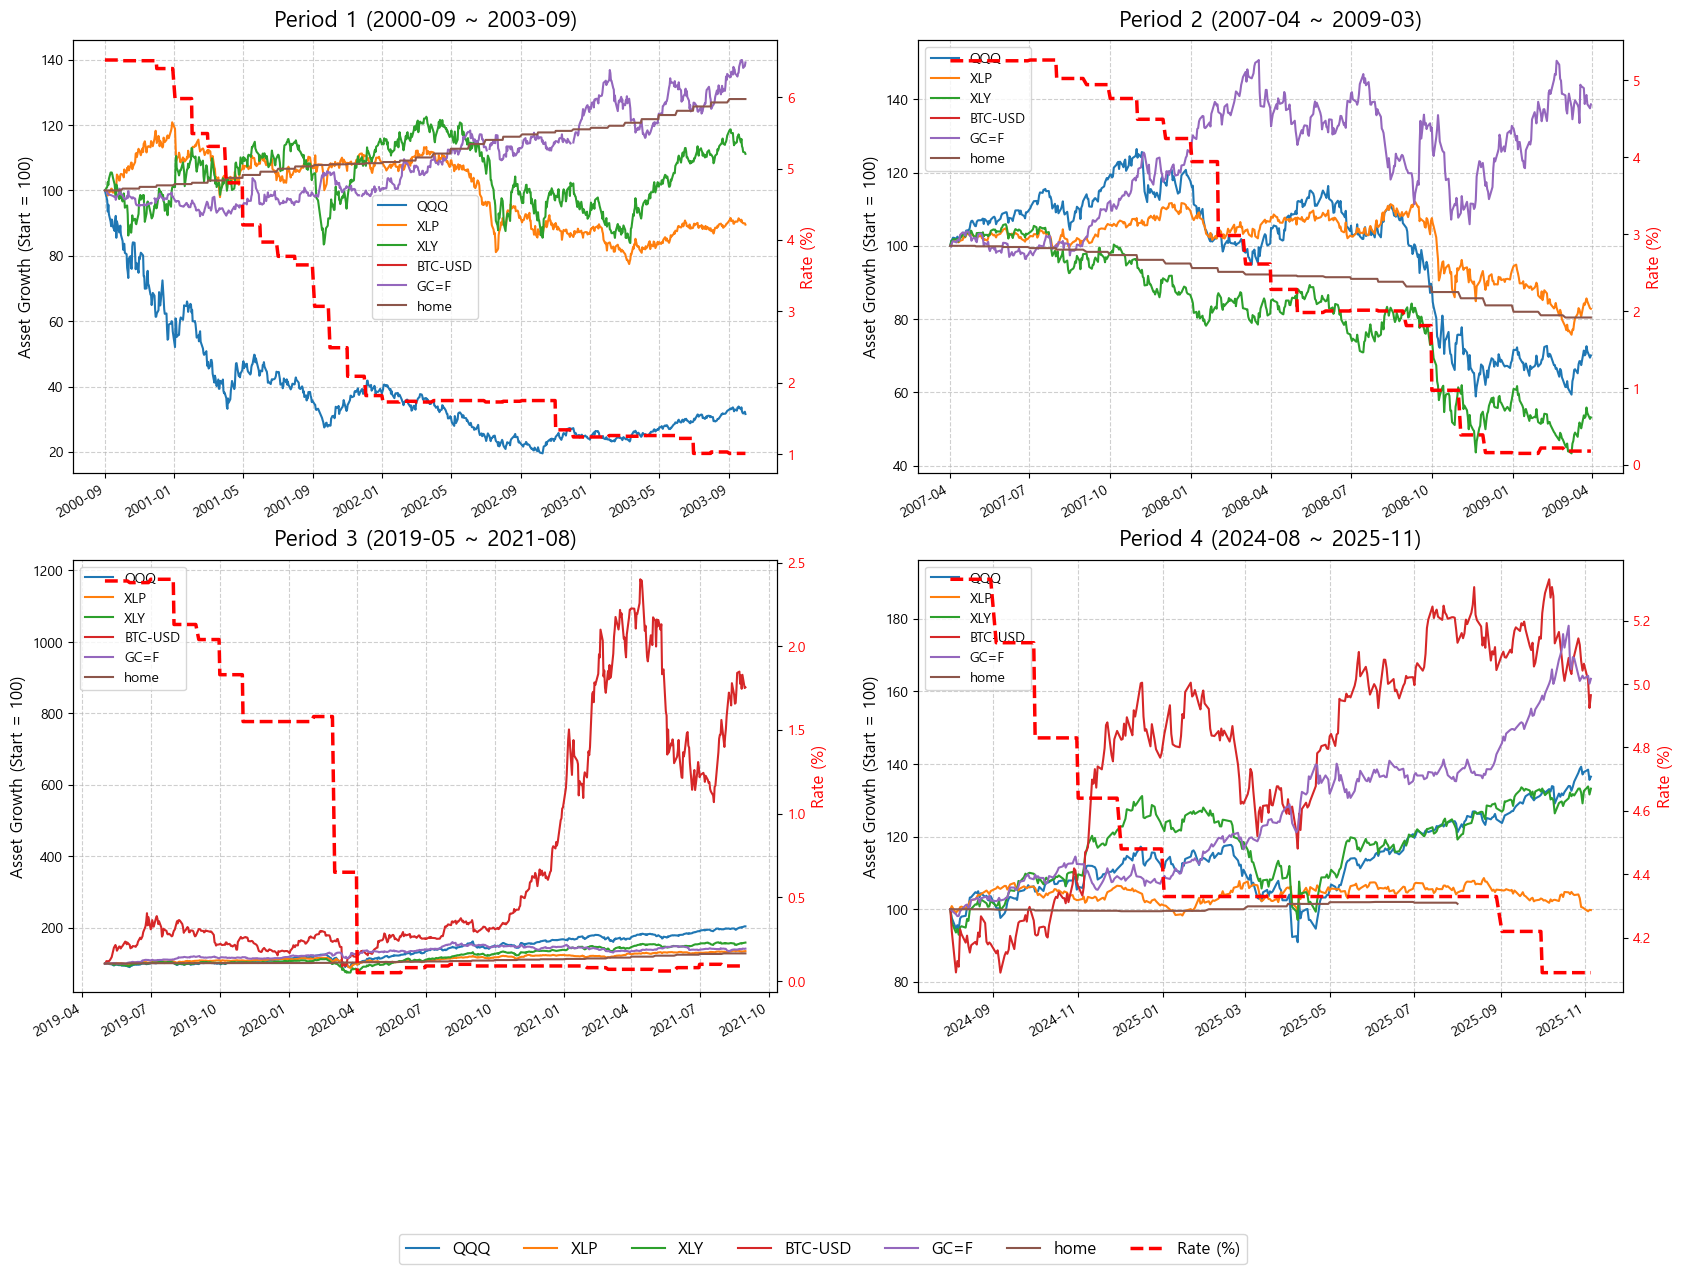

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# (가정) 이전에 데이터 준비 코드가 모두 실행되어
# 'final_data' DataFrame이 메모리에 존재해야 합니다.

# 1. (★수정★) 파일 로드 대신, 메모리에 있는 'final_data'를 'df'로 사용
try:
    df = final_data.copy()
    if not isinstance(df.index, pd.DatetimeIndex):
        df = df.set_index('Date')
        
except NameError:
    print("Error: 'final_data' 변수가 메모리에 없습니다.")
    print("먼저 데이터 준비 코드를 실행해주세요.")
    exit()

# 2. (★수정 1★) asset_cols 리스트에 'home'을 추가합니다.
asset_cols = ['QQQ', 'XLP', 'XLY', 'BTC-USD', 'GC=F', 'home'] 

# 3. 기간(period) 리스트 확보
periods = df['period'].unique()
periods.sort() 

# 4. 2x2 서브플롯 생성
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 14), sharex=False)
axes = axes.flatten() 

# (참고용) 각 기간의 실제 날짜 범위
period_info = {}
for p in periods:
    period_data = df[df['period'] == p]
    if not period_data.empty:
        start = period_data.index.min().strftime('%Y-%m')
        end = period_data.index.max().strftime('%Y-%m')
        period_info[p] = f'Period {p} ({start} ~ {end})'
    else:
        period_info[p] = f'Period {p} (No Data)'

# 범례 수집용 딕셔너리
legend_map = {}

# 5. 각 기간(period)별로 루프를 돌며 그래프 그리기
for i, p_num in enumerate(periods):
    if i >= len(axes): 
        break
        
    ax = axes[i]  
    df_period = df[df['period'] == p_num]

    # --- (핵심) 정규화: (현재가 / 기간 첫날 가격) * 100 ---
    # (★수정 1★) 'home'이 'asset_cols'에 포함되었으므로 여기서 함께 처리됩니다.
    try:
        df_norm = (df_period[asset_cols] / df_period[asset_cols].iloc[0]) * 100
    except Exception as e:
        print(f"Error normalizing data for period {p_num}: {e}")
        continue
    
    # 5a. (왼쪽 Y축) 정규화된 자산 가격 플롯
    # (이제 'home'이 포함된 df_norm이 그려집니다)
    df_norm.plot(ax=ax, linewidth=1.5) 
    ax.set_ylabel('Asset Growth (Start = 100)', fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_title(period_info[p_num], fontsize=16, pad=10)
    ax.set_xlabel('') 
    
    # 5b. (오른쪽 Y축) 금리(rate) 플롯
    ax_twin = ax.twinx()
    ax_twin.plot(df_period.index, df_period['rate'], 
                 color='red', linestyle='--', label='Rate (%)', linewidth=2.5)
    

    ax_twin.set_ylabel('Rate (%)', color='red', fontsize=12)
    ax_twin.tick_params(axis='y', labelcolor='red')
    
    # X축 날짜 포맷팅
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

    # 범례 수집
    lines, labels = ax.get_legend_handles_labels()
    lines_twin, labels_twin = ax_twin.get_legend_handles_labels()
    
    for line, label in zip(lines + lines_twin, labels + labels_twin):
        if label not in legend_map:
            legend_map[label] = line


# 6. 수집된 범례 생성 (ncol=8)
# (6 assets + 1 cpi + 1 rate = 8)
try:
    fig.legend(legend_map.values(), legend_map.keys(), 
               loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=8, fontsize=12)
except Exception as e:
    print(f"Legend generation error: {e}")

# 7. 전체 제목 및 레이